# Import the dataset

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(r"C:\Users\hp\OneDrive\Documents\Desktop\ML\datasets\training.csv")
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# Understand the dataset

In [25]:
print("Shape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset:
(614, 13)

Column names:
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     

# Basic statistics

In [26]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [27]:
df.describe(include="object")

C:\Users\hp\AppData\Local\Temp\ipykernel_4020\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP001002,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


# Data Cleaning

In [30]:
df = df.drop("Loan_ID", axis=1)

print(df.head())

  Gender Married Dependents     Education Self_Employed  ApplicantIncome  \
0   Male      No          0      Graduate            No             5849   
1   Male     Yes          1      Graduate            No             4583   
2   Male     Yes          0      Graduate           Yes             3000   
3   Male     Yes          0  Not Graduate            No             2583   
4   Male      No          0      Graduate            No             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0         NaN             360.0             1.0   
1             1508.0       128.0             360.0             1.0   
2                0.0        66.0             360.0             1.0   
3             2358.0       120.0             360.0             1.0   
4                0.0       141.0             360.0             1.0   

  Property_Area Loan_Status  
0         Urban           Y  
1         Rural           N  
2         Urban           Y  
3 

Fill missing categorical values

In [31]:
categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Self_Employed"
]

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

Fill missing numerical values

In [32]:
numerical_columns = [
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

Check missing values again

In [33]:
print(df.isnull().sum())

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


# Exploratory Data Analysis (EDA)

Check Loan Status distribution

In [34]:
print(df["Loan_Status"].value_counts())

Loan_Status
Y    422
N    192
Name: count, dtype: int64


Loan Status distribution

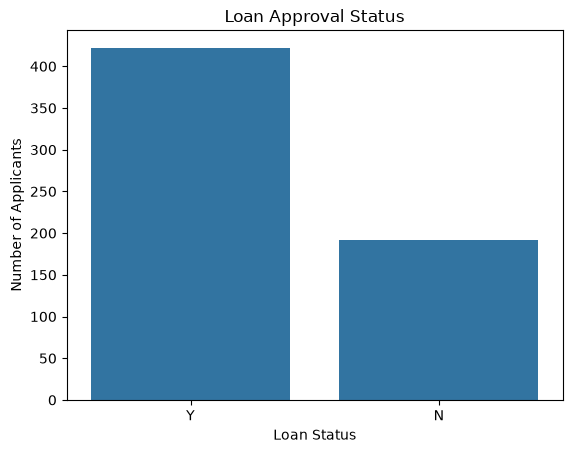

In [35]:
sns.countplot(x="Loan_Status", data=df)
plt.title("Loan Approval Status")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")
plt.show()

Check categorical variables

In [36]:
categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area"
]

for col in categorical_columns:
    print("\n", col)
    print(df[col].value_counts())


 Gender
Gender
Male      502
Female    112
Name: count, dtype: int64

 Married
Married
Yes    401
No     213
Name: count, dtype: int64

 Dependents
Dependents
0     360
1     102
2     101
3+     51
Name: count, dtype: int64

 Education
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

 Self_Employed
Self_Employed
No     532
Yes     82
Name: count, dtype: int64

 Property_Area
Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64


Numerical data summary

In [37]:
numerical_columns = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

print(df[numerical_columns].describe())

       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000         614.000000  614.000000        614.000000   
mean       5403.459283        1621.245798  145.752443        342.410423   
std        6109.041673        2926.248369   84.107233         64.428629   
min         150.000000           0.000000    9.000000         12.000000   
25%        2877.500000           0.000000  100.250000        360.000000   
50%        3812.500000        1188.500000  128.000000        360.000000   
75%        5795.000000        2297.250000  164.750000        360.000000   
max       81000.000000       41667.000000  700.000000        480.000000   

       Credit_History  
count      614.000000  
mean         0.855049  
std          0.352339  
min          0.000000  
25%          1.000000  
50%          1.000000  
75%          1.000000  
max          1.000000  


EDA graph

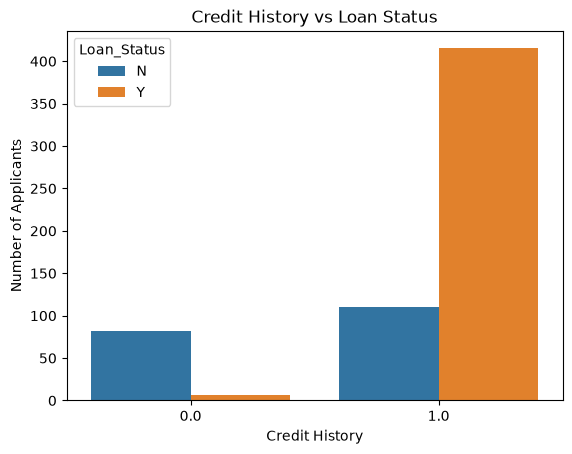

In [38]:
sns.countplot(x="Credit_History", hue="Loan_Status", data=df)
plt.title("Credit History vs Loan Status")
plt.xlabel("Credit History")
plt.ylabel("Number of Applicants")
plt.show()

# Data Preprocessing

Convert categorical columns into numbers

In [41]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Loan_Status"
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

print(df.head())

   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0           0          0              0             5849   
1       1        1           1          0              0             4583   
2       1        1           0          0              1             3000   
3       1        1           0          1              0             2583   
4       1        0           0          0              0             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0       128.0             360.0             1.0   
1             1508.0       128.0             360.0             1.0   
2                0.0        66.0             360.0             1.0   
3             2358.0       120.0             360.0             1.0   
4                0.0       141.0             360.0             1.0   

   Property_Area  Loan_Status  
0              2            1  
1              0            0  
2              2    

In [42]:
print(df.dtypes)

Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
dtype: object


In [43]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (614, 11)
y shape: (614,)


# Training and testing data

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (491, 11)
Testing data: (123, 11)


# Linear Regression

Linear Regression Predictions:
[ 0.03688286  0.84578377  0.78371498  0.82348487  0.82787514  0.73262368
  0.8363675   0.79090916  0.74118323  0.65050467  0.80713911  0.75340159
  0.84567052  0.8036148   0.13114745  0.05222172  0.7323582   0.0700905
  0.07429222  0.7736016   0.1604862   0.63455233  0.39095126  0.806251
  0.81181348  0.74641441  0.78768102  0.73231004  0.04946601  0.80278702
  0.83910171  0.84166404  0.82247066  0.82321604  0.68000899  0.74193579
  0.03686903  0.85732846  0.76861516  0.81288012  0.85803033  0.73636394
  0.80624584  0.83009906  0.76783517  0.82285539  0.83236816  0.83203709
  0.78061717  0.60174332  0.1402248   0.8475309   0.02580628  0.77443695
  0.64553406  0.7860006   0.08915026  0.84998571  0.87015214  0.63967709
  0.07345895  0.66142051  0.73025452  0.77132122  0.80341725  0.7323608
  0.87031518  0.87793707  0.67181625  0.86563781  0.85806891  0.14079753
  0.88220035  0.77230055  0.88966249  0.74114396  0.8106283   0.86823867
  0.84257993  0.09513245

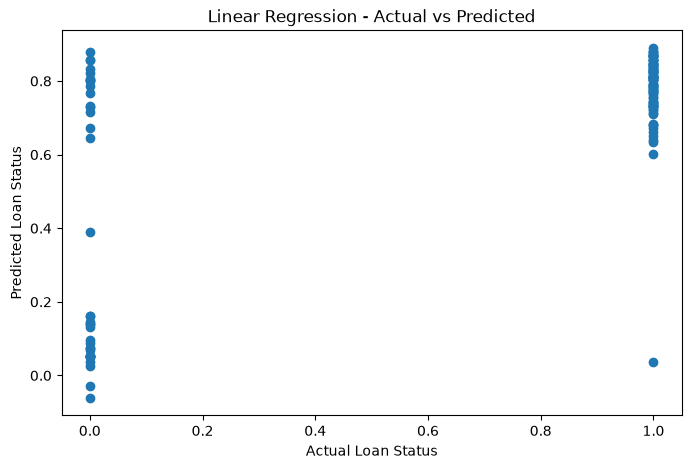

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

#Create Linear Regression model
linear_model = LinearRegression()

#Train the model
linear_model.fit(X_train, y_train)

#Make predictions
y_pred_linear = linear_model.predict(X_test)

#Display predictions
print("Linear Regression Predictions:")
print(y_pred_linear)

#Convert predictions into 0/1
y_pred_linear_class = (y_pred_linear >= 0.5).astype(int)

#Calculate regression metrics
mae = mean_absolute_error(y_test, y_pred_linear)
mse = mean_squared_error(y_test, y_pred_linear)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_linear)
print("\nLinear Regression Metrics:")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)

#Calculate classification accuracy
linear_accuracy = np.mean(y_pred_linear_class == y_test)
print("\nLinear Regression Classification Accuracy:")
print("Accuracy:", linear_accuracy)
print("Accuracy (%):", linear_accuracy * 100)

#Actual vs Predicted values
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_linear)
plt.xlabel("Actual Loan Status")
plt.ylabel("Predicted Loan Status")
plt.title("Linear Regression - Actual vs Predicted")
plt.show()

# Logistic Regression

[0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1
 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1
 1 1 1 1 1 1 1 1 0 0 1 0]
Logistic Regression Accuracy: 0.8617886178861789
Logistic Regression Accuracy (%): 86.1788617886179


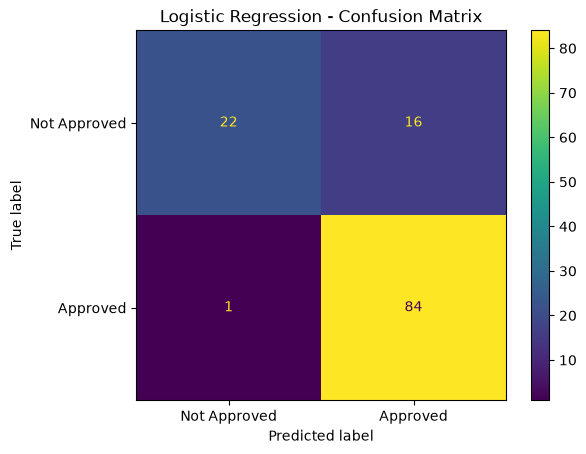

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix, ConfusionMatrixDisplay, classification_report

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(random_state=42)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print(y_pred_log)

log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)
print("Logistic Regression Accuracy (%):", log_accuracy * 100)

cm = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Approved", "Approved"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log))




# K-Nearest Neighbors (KNN)

KNN Predictions:
[0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 0
 1 1 1 1 1 1 1 1 0 1 1 1 0 0 1 0 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1
 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1
 1 1 1 1 1 1 1 1 0 0 1 0]

KNN Accuracy: 0.8455284552845529
KNN Accuracy (%): 84.5528455284553


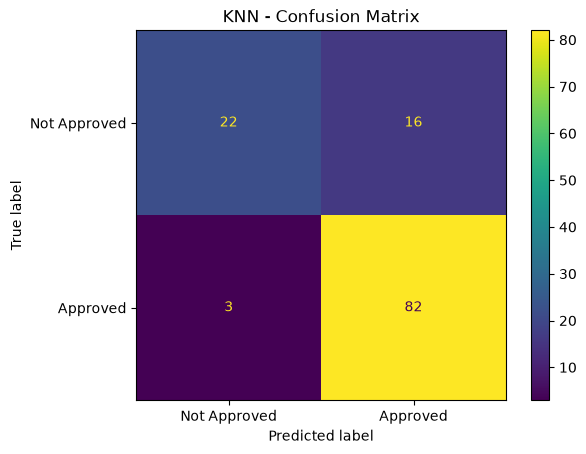


KNN Classification Report:
              precision    recall  f1-score   support

Not Approved       0.88      0.58      0.70        38
    Approved       0.84      0.96      0.90        85

    accuracy                           0.85       123
   macro avg       0.86      0.77      0.80       123
weighted avg       0.85      0.85      0.84       123



In [60]:
#Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

#Create KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

#Train the model
knn_model.fit(X_train_scaled, y_train)

#Make predictions
y_pred_knn = knn_model.predict(X_test_scaled)

#Display predictions
print("KNN Predictions:")
print(y_pred_knn)

#Calculate accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print("\nKNN Accuracy:", knn_accuracy)
print("KNN Accuracy (%):", knn_accuracy * 100)

#Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=["Not Approved", "Approved"]
)
disp.plot()
plt.title("KNN - Confusion Matrix")
plt.show()

#Classification Report
print("\nKNN Classification Report:")
print(classification_report(
    y_test,
    y_pred_knn,
    target_names=["Not Approved", "Approved"]
))

# DECISION TREE CLASSIFICATION

Decision Tree Predictions:
[0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 0 1 1 1 0 0 1 1 1 1 1 1 0 1 1 0 1 0
 1 1 1 1 1 0 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 0 0 1 0]

Decision Tree Accuracy: 0.8211382113821138
Decision Tree Accuracy (%): 82.11382113821138


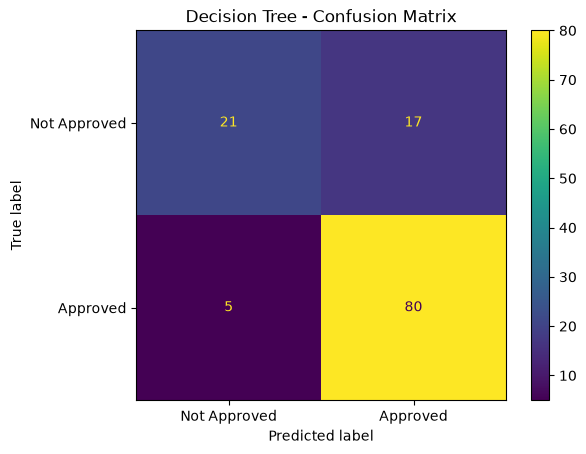


Decision Tree Classification Report:
              precision    recall  f1-score   support

Not Approved       0.81      0.55      0.66        38
    Approved       0.82      0.94      0.88        85

    accuracy                           0.82       123
   macro avg       0.82      0.75      0.77       123
weighted avg       0.82      0.82      0.81       123



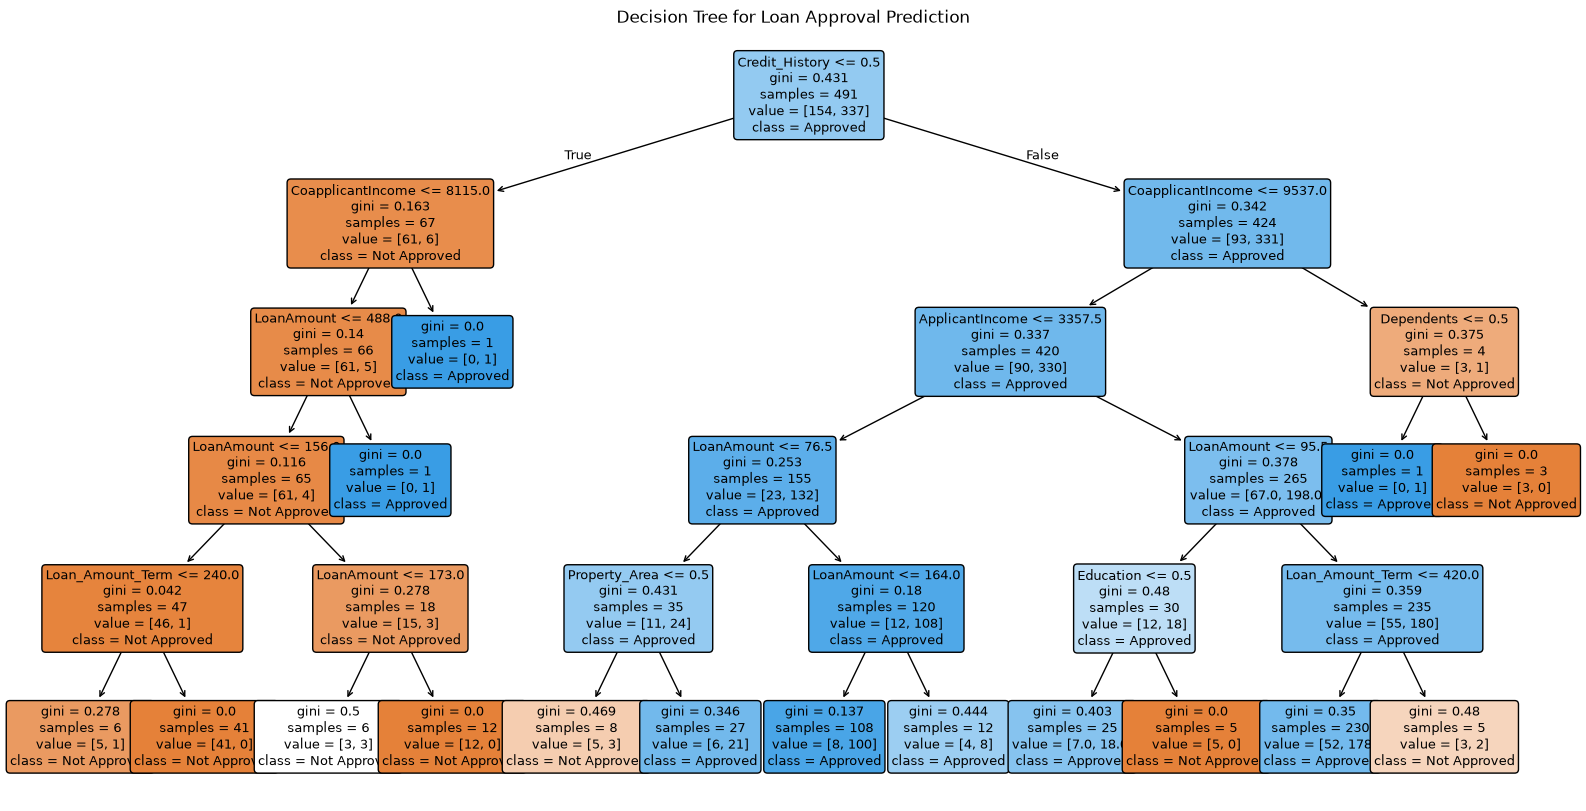

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

#Create Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

#Train the model
dt_model.fit(X_train, y_train)

#Make predictions
y_pred_dt = dt_model.predict(X_test)

#Display predictions
print("Decision Tree Predictions:")
print(y_pred_dt)

#Calculate accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("\nDecision Tree Accuracy:", dt_accuracy)
print("Decision Tree Accuracy (%):", dt_accuracy * 100)

#Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["Not Approved", "Approved"]
)
disp.plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()

#Classification Report
print("\nDecision Tree Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=["Not Approved", "Approved"]
    )
)

#Display the Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["Not Approved", "Approved"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree for Loan Approval Prediction")
plt.show()

                 Model  Accuracy
0    Linear Regression  0.861789
1  Logistic Regression  0.861789
2                  KNN  0.845528
3        Decision Tree  0.821138

Model Comparison:
                 Model  Accuracy  Accuracy (%)
0    Linear Regression  0.861789     86.178862
1  Logistic Regression  0.861789     86.178862
2                  KNN  0.845528     84.552846
3        Decision Tree  0.821138     82.113821


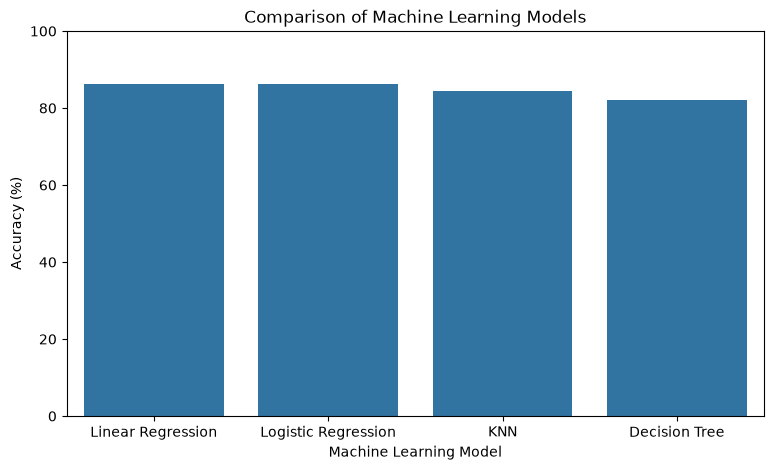

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Logistic Regression",
        "KNN",
        "Decision Tree"
    ],
    "Accuracy": [
        linear_accuracy,
        log_accuracy,
        knn_accuracy,
        dt_accuracy
    ]
})

print(model_results)

# Convert accuracy to percentage
model_results["Accuracy (%)"] = model_results["Accuracy"] * 100

print("\nModel Comparison:")
print(model_results)

# Plot
plt.figure(figsize=(9, 5))

sns.barplot(
    x="Model",
    y="Accuracy (%)",
    data=model_results
)

plt.title("Comparison of Machine Learning Models")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

plt.show()